
# 🐍 Reconocimiento de Especies de Serpientes mediante Visión por Computadora

Notebook end-to-end para:

1. Descargar y explorar un dataset de especies de serpientes desde **Kaggle**.
2. Entrenar un **detector de presencia** (¿hay o no una serpiente en la imagen?).
3. Entrenar un **clasificador de especies** robusto a clases desbalanceadas (Transfer Learning + Focal Loss + Class Weights + Augmentations agresivas + Weighted Sampling).
4. Generar explicabilidad con **Grad-CAM** sobre las predicciones.

**Pipeline de inferencia final:**

```
imagen -> ¿es serpiente? (modelo de presencia)
            |-- NO (baja confianza / clase Non-Snake) -> "No se detectó ninguna serpiente"
            |-- SÍ -> clasificador de especies -> especie + confianza + mapa de calor Grad-CAM
```

> ⚠️ Ajusta los identificadores de dataset de Kaggle (`KAGGLE_SNAKE_DATASET` y `KAGGLE_NEGATIVE_DATASET`) si en tu cuenta prefieres otra fuente equivalente.



## 🧩 Paso 1 — Configuración del entorno, GPU y descarga del dataset desde Kaggle

- Instalamos las dependencias necesarias.
- Verificamos disponibilidad de GPU.
- Configuramos las credenciales de la API de Kaggle (`kaggle.json`).
- Descargamos:
  - **Dataset positivo**: especies de serpientes → [`vencerlanz09/snake-species-image-dataset`](https://www.kaggle.com/datasets/vencerlanz09/snake-species-image-dataset) (dataset balanceado y variado, ~17 especies).
  - **Dataset negativo (Non-Snake)**: imágenes de otros animales/fondos, usado para entrenar el filtro de presencia → [`alessiocorrado99/animals10`](https://www.kaggle.com/datasets/alessiocorrado99/animals10) (no contiene serpientes).


In [ ]:

# --- Instalación de dependencias ---
!pip install -q kagglehub kaggle timm albumentations grad-cam opencv-python-headless \
                torch torchvision scikit-learn seaborn tqdm --upgrade


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 69.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 97.9 MB/s

In [1]:

import os, sys, json, glob, random, shutil, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Dispositivo activo: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️ No se detectó GPU. El entrenamiento será más lento (recomendado usar Colab/Kaggle con GPU).")


✅ Dispositivo activo: cpu
   ⚠️ No se detectó GPU. El entrenamiento será más lento (recomendado usar Colab/Kaggle con GPU).


In [2]:

# --- Configuración de credenciales de Kaggle ---
# Opción A (recomendada en Colab): sube tu archivo kaggle.json y ejecuta:
#
# from google.colab import files
# files.upload()  # selecciona kaggle.json
# os.makedirs("/root/.kaggle", exist_ok=True)
# shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
# os.chmod("/root/.kaggle/kaggle.json", 0o600)
#
# Opción B: define las variables de entorno directamente (no recomendado compartir el notebook con esto relleno)
os.environ["KAGGLE_USERNAME"] = "edymartinez22"
os.environ["KAGGLE_KEY"] = "KGAT_f71565a1d04efe5407e0a19cd62c58d5"

KAGGLE_JSON_PATH = os.path.expanduser("~/.kaggle/kaggle.json")
if os.path.exists(KAGGLE_JSON_PATH):
    print("✅ Credenciales de Kaggle encontradas.")
elif "KAGGLE_USERNAME" in os.environ and "KAGGLE_KEY" in os.environ:
    print("✅ Credenciales de Kaggle definidas por variables de entorno.")
else:
    print("⚠️ No se encontraron credenciales de Kaggle. Configúralas antes de continuar (ver instrucciones arriba).")


✅ Credenciales de Kaggle definidas por variables de entorno.


In [ ]:
# --- Descarga directa mediante la CLI de Kaggle ---
!!kaggle datasets download -d chandrashekarnatesh/slithering-serpents-image-classification-dataset --unzip -p ./data/snakes
!!kaggle datasets download -d alessiocorrado99/animals10 --unzip -p ./data/negatives

# Asignamos las rutas para que el resto del notebook funcione transparente
snake_dataset_path = "./data/snakes"
negative_dataset_path = "./data/negatives"

print("✅ Datasets descargados y descomprimidos con éxito.")


Dataset URL: https://www.kaggle.com/datasets/chandrashekarnatesh/slithering-serpents-image-classification-dataset
License(s): apache-2.0
100% 2.30G/2.30G [00:24<00:00, 98.8MB/s]



In [ ]:
import os

# Apuntamos directo a 'train' donde están agrupadas las carpetas de especies
SNAKE_ROOT = "./data/snakes/dataset/dataset/train"  # o ajusta según la ruta real exacta
NEGATIVE_ROOT = "./data/negatives/raw-img"

print("🐍 Especies de serpientes detectadas:")
print(os.listdir(SNAKE_ROOT)[:10])

print("\n🚫 Categorías negativas detectadas:")
print(os.listdir(NEGATIVE_ROOT)[:10])

🐍 Especies de serpientes detectadas:
['Caspian cobra', 'Banded water cobra', 'Texas coral snake', 'Andaman cobra', 'Spectacled cobra', 'Black snake', 'Harlequin coral snake', 'Red-bellied black snake', 'Puerto rican boa', 'King cobra']

🚫 Categorías negativas detectadas:
['farfalla', 'scoiattolo', 'mucca', 'ragno', 'gallina', 'gatto', 'cane', 'pecora', 'cavallo', 'elefante']



## 🔎 Paso 2 — Análisis Exploratorio de Datos (EDA)

Construimos un `DataFrame` con la ruta y la especie de cada imagen, contamos ejemplos por clase,
visualizamos el desbalance y mostramos una muestra visual por especie.


In [ ]:

VALID_EXT = (".jpg", ".jpeg", ".png", ".bmp")

def build_dataframe(root_dir):
    rows = []
    for species in sorted(os.listdir(root_dir)):
        species_dir = os.path.join(root_dir, species)
        if not os.path.isdir(species_dir):
            continue
        for fname in os.listdir(species_dir):
            if fname.lower().endswith(VALID_EXT):
                rows.append({"filepath": os.path.join(species_dir, fname), "label": species})
    return pd.DataFrame(rows)

df_species = build_dataframe(SNAKE_ROOT)
print(f"Total de imágenes de serpientes: {len(df_species)}")
print(f"Número de especies: {df_species['label'].nunique()}")
df_species.head()


Total de imágenes de serpientes: 53823
Número de especies: 80


,filepath,label
0,./data/snakes/dataset/dataset/train/Abaco isla...,Abaco island boa
1,./data/snakes/dataset/dataset/train/Abaco isla...,Abaco island boa
2,./data/snakes/dataset/dataset/train/Abaco isla...,Abaco island boa
3,./data/snakes/dataset/dataset/train/Abaco isla...,Abaco island boa
4,./data/snakes/dataset/dataset/train/Abaco isla...,Abaco island boa


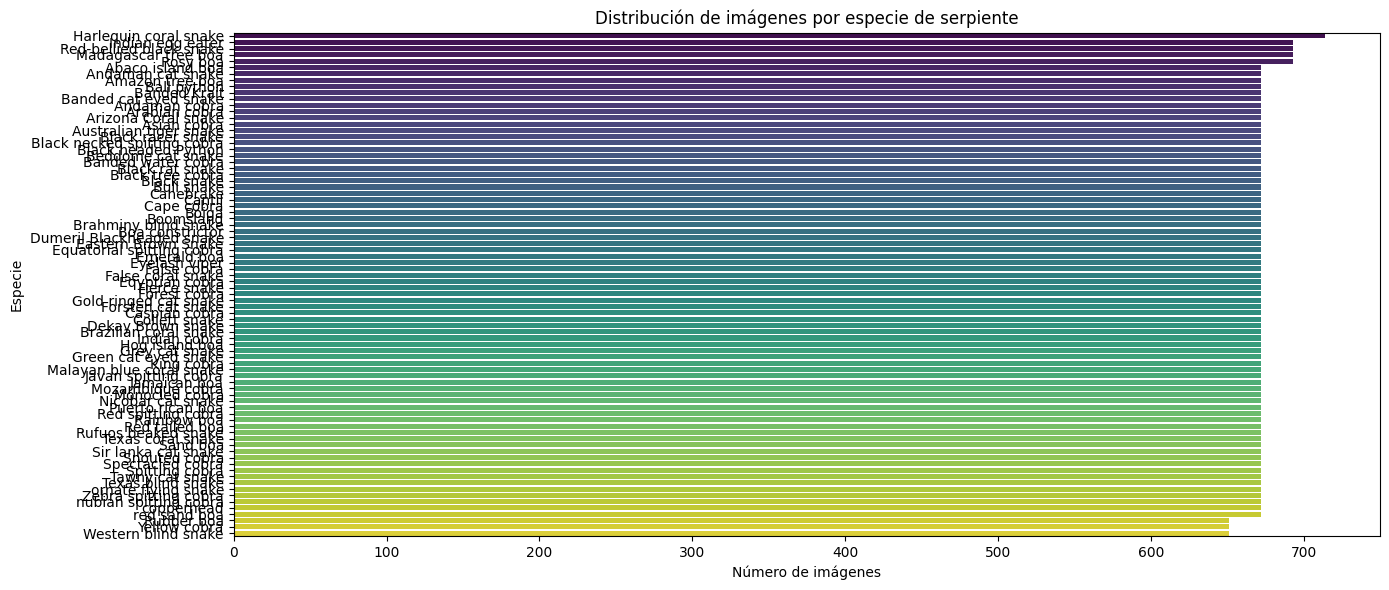

Mediana de imágenes por clase: 672
Umbral de clase minoritaria (50% de la mediana): 336
Clases minoritarias detectadas (0): []


In [ ]:

# --- Distribución de clases (desbalance) ---
class_counts = df_species["label"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis")
plt.title("Distribución de imágenes por especie de serpiente")
plt.xlabel("Número de imágenes")
plt.ylabel("Especie")
plt.tight_layout()
plt.show()

MEDIAN_COUNT = class_counts.median()
MINORITY_THRESHOLD = MEDIAN_COUNT * 0.5
minority_classes = class_counts[class_counts < MINORITY_THRESHOLD].index.tolist()

print(f"Mediana de imágenes por clase: {MEDIAN_COUNT:.0f}")
print(f"Umbral de clase minoritaria (50% de la mediana): {MINORITY_THRESHOLD:.0f}")
print(f"Clases minoritarias detectadas ({len(minority_classes)}): {minority_classes}")


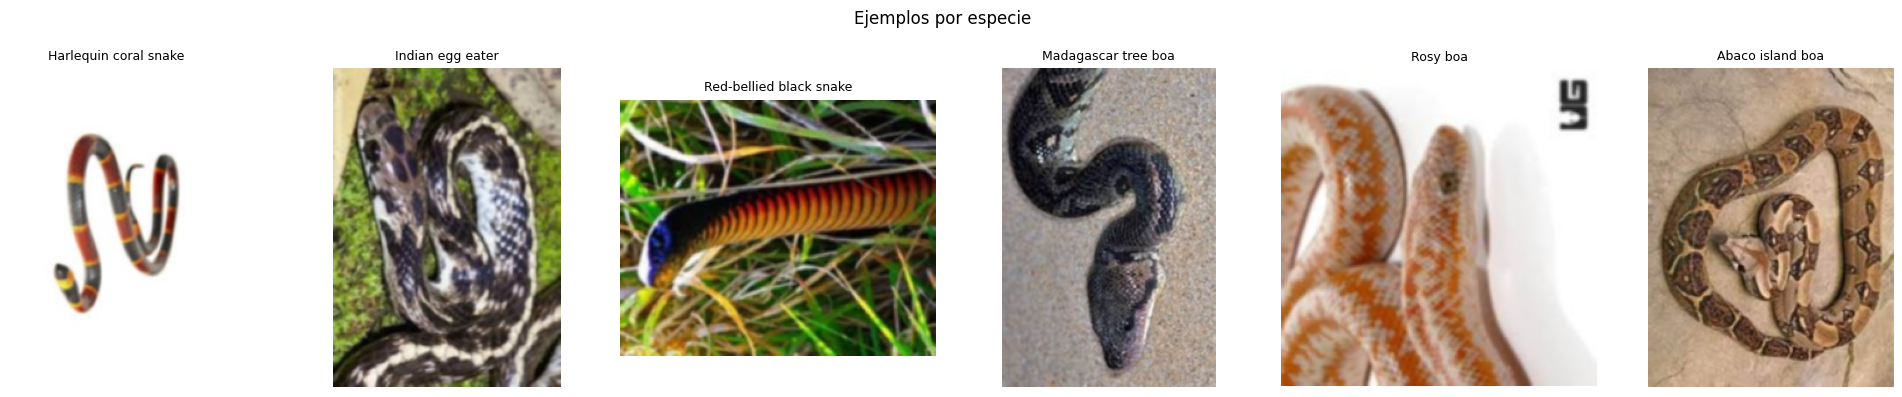

In [ ]:

# --- Muestra visual de algunas especies ---
sample_species = class_counts.index[:6]
fig, axes = plt.subplots(1, len(sample_species), figsize=(20, 4))
for ax, sp in zip(axes, sample_species):
    sample_path = df_species[df_species["label"] == sp]["filepath"].iloc[0]
    img = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(sp, fontsize=9)
    ax.axis("off")
plt.suptitle("Ejemplos por especie")
plt.tight_layout()
plt.show()



## 🧪 Paso 3 — Preprocesamiento, Augmentation y DataLoaders balanceados

Estrategia contra el desbalance de clases:

1. **Split estratificado** train/val/test (70/15/15) para preservar la proporción de cada especie.
2. **Augmentations intensas** (Albumentations) aplicadas de forma más agresiva a las **clases minoritarias**.
3. **`WeightedRandomSampler`**: sobre-muestrea clases minoritarias en cada batch de entrenamiento.
4. **Class Weights** calculados para usarse en la función de pérdida (Paso 4).
5. **Dataset binario de presencia** (Snake vs Non-Snake) combinando el dataset positivo y el negativo.


In [ ]:

label_encoder = {label: idx for idx, label in enumerate(sorted(df_species["label"].unique()))}
idx_to_label = {v: k for k, v in label_encoder.items()}
df_species["target"] = df_species["label"].map(label_encoder)
NUM_CLASSES = len(label_encoder)
print(f"Número de clases de especies: {NUM_CLASSES}")

train_df, temp_df = train_test_split(
    df_species, test_size=0.30, stratify=df_species["target"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["target"], random_state=SEED
)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Número de clases de especies: 80
Train: 37676 | Val: 8073 | Test: 8074


In [ ]:

import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Augmentation estándar (clases mayoritarias)
base_train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# Augmentation intensa (clases minoritarias): más agresiva y variada
heavy_train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=35, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=25, val_shift_limit=15, p=0.5),
    A.CoarseDropout(max_holes=6, max_height=24, max_width=24, p=0.4),
    A.GaussNoise(var_limit=(10.0, 40.0), p=0.3),
    A.OneOf([
        A.MotionBlur(blur_limit=3, p=1.0),
        A.GaussianBlur(blur_limit=3, p=1.0),
    ], p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

minority_target_ids = set(label_encoder[c] for c in minority_classes)


In [ ]:

class SnakeSpeciesDataset(Dataset):
    '''Dataset de especies. Aplica augmentation intensa a las clases minoritarias.'''
    def __init__(self, dataframe, base_transform, heavy_transform, minority_ids, is_train=True):
        self.df = dataframe.reset_index(drop=True)
        self.base_transform = base_transform
        self.heavy_transform = heavy_transform
        self.minority_ids = minority_ids
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row["filepath"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        target = int(row["target"])

        if self.is_train:
            transform = self.heavy_transform if target in self.minority_ids else self.base_transform
        else:
            transform = self.base_transform
        augmented = transform(image=img)
        return augmented["image"], target


train_dataset = SnakeSpeciesDataset(train_df, base_train_tf, heavy_train_tf, minority_target_ids, is_train=True)
val_dataset   = SnakeSpeciesDataset(val_df, eval_tf, eval_tf, minority_target_ids, is_train=False)
test_dataset  = SnakeSpeciesDataset(test_df, eval_tf, eval_tf, minority_target_ids, is_train=False)

# --- WeightedRandomSampler: sobre-muestrea clases minoritarias ---
class_sample_counts = train_df["target"].value_counts().sort_index().values
class_weights_for_sampler = 1.0 / class_sample_counts
sample_weights = train_df["target"].map(lambda t: class_weights_for_sampler[t]).values
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Batches -> train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")


Batches -> train: 1178 | val: 253 | test: 253


In [ ]:

# --- Class weights para la función de pérdida (Paso 4) ---
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["target"].values,
)
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float32).to(DEVICE)
print("Class weights (primeros 10):", class_weights_array[:10])


Class weights (primeros 10): [0.99989384 1.00202128 1.00202128 1.00202128 0.99989384 0.99989384
 1.00202128 0.99989384 1.00202128 0.99989384]


In [ ]:

# --- Dataset binario de PRESENCIA: Snake (1) vs Non-Snake (0) ---
def build_binary_dataframe(snake_root, negative_root, max_negative_per_class=300):
    rows = []
    for species in os.listdir(snake_root):
        species_dir = os.path.join(snake_root, species)
        if not os.path.isdir(species_dir):
            continue
        for fname in os.listdir(species_dir):
            if fname.lower().endswith(VALID_EXT):
                rows.append({"filepath": os.path.join(species_dir, fname), "presence": 1})

    for category in os.listdir(negative_root):
        cat_dir = os.path.join(negative_root, category)
        if not os.path.isdir(cat_dir):
            continue
        files = [f for f in os.listdir(cat_dir) if f.lower().endswith(VALID_EXT)][:max_negative_per_class]
        for fname in files:
            rows.append({"filepath": os.path.join(cat_dir, fname), "presence": 0})

    return pd.DataFrame(rows)

df_presence = build_binary_dataframe(SNAKE_ROOT, NEGATIVE_ROOT)
print(df_presence["presence"].value_counts())

pres_train_df, pres_temp_df = train_test_split(
    df_presence, test_size=0.3, stratify=df_presence["presence"], random_state=SEED
)
pres_val_df, pres_test_df = train_test_split(
    pres_temp_df, test_size=0.5, stratify=pres_temp_df["presence"], random_state=SEED
)


class PresenceDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row["filepath"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented = self.transform(image=img)
        return augmented["image"], int(row["presence"])


presence_train_ds = PresenceDataset(pres_train_df, base_train_tf)
presence_val_ds   = PresenceDataset(pres_val_df, eval_tf)
presence_test_ds  = PresenceDataset(pres_test_df, eval_tf)

presence_train_loader = DataLoader(presence_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
presence_val_loader   = DataLoader(presence_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
presence_test_loader  = DataLoader(presence_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


presence
1    53823
0     3000
Name: count, dtype: int64



## 🏗️ Paso 4 — Arquitectura (Transfer Learning) y estrategia de pérdida

- **Backbone**: `EfficientNet-B0` preentrenado en ImageNet (robusto y eficiente) para ambos modelos.
- **Modelo de presencia**: cabeza binaria (Snake / Non-Snake).
- **Modelo de especies**: cabeza multi-clase (una por especie).
- **Pérdida**: `Focal Loss` con `class weights` incorporados — reduce el peso de ejemplos fáciles/mayoritarios y refuerza el aprendizaje sobre clases minoritarias/difíciles.


In [ ]:

class FocalLoss(nn.Module):
    '''Focal Loss multi-clase con soporte de class weights (alpha por clase).'''
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha  # tensor [num_classes] o None
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_term = (1 - pt) ** self.gamma
        loss = focal_term * ce_loss
        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


In [ ]:

def build_efficientnet_classifier(num_classes, pretrained=True, freeze_backbone=False):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.efficientnet_b0(weights=weights)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model


# --- Modelo de presencia (binario: Snake vs Non-Snake) ---
presence_model = build_efficientnet_classifier(num_classes=2, pretrained=True, freeze_backbone=False).to(DEVICE)

# --- Modelo de especies (multi-clase) ---
species_model = build_efficientnet_classifier(num_classes=NUM_CLASSES, pretrained=True, freeze_backbone=False).to(DEVICE)

print(species_model.classifier)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 185MB/s]


Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=80, bias=True)
)


In [ ]:

# --- Función de pérdida y optimizadores ---
presence_criterion = nn.CrossEntropyLoss()
species_criterion  = FocalLoss(alpha=class_weights_tensor, gamma=2.0)

presence_optimizer = torch.optim.AdamW(presence_model.parameters(), lr=1e-4, weight_decay=1e-4)
species_optimizer  = torch.optim.AdamW(species_model.parameters(), lr=1e-4, weight_decay=1e-4)

presence_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(presence_optimizer, mode="min", factor=0.5, patience=2)
species_scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(species_optimizer, mode="min", factor=0.5, patience=2)



## 🚂 Paso 5 — Entrenamiento con validación y guardado del mejor modelo

Función de entrenamiento genérica reutilizada para el modelo de **presencia** y el de **especies**,
con **early stopping** implícito vía guardado del mejor checkpoint según F1 de validación.


In [ ]:

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                 num_epochs, checkpoint_path, patience=5):
    best_val_f1 = -1.0
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

    for epoch in range(1, num_epochs + 1):
        # ---- Entrenamiento ----
        model.train()
        running_loss = 0.0
        loop = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [train]", leave=False)
        for images, targets in loop:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            loop.set_postfix(loss=loss.item())
        train_loss = running_loss / len(train_loader.dataset)

        # ---- Validación ----
        model.eval()
        val_running_loss = 0.0
        all_preds, all_targets = [], []
        with torch.no_grad():
            for images, targets in val_loader:
                images, targets = images.to(DEVICE), targets.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, targets)
                val_running_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = np.mean(np.array(all_preds) == np.array(all_targets))
        val_f1 = f1_score(all_targets, all_preds, average="macro")

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(f"Epoch {epoch}/{num_epochs} -> train_loss: {train_loss:.4f} | "
              f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f} | val_f1(macro): {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            epochs_no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f"   💾 Nuevo mejor modelo guardado en '{checkpoint_path}' (val_f1={val_f1:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"⏹️ Early stopping en epoch {epoch} (sin mejora en {patience} épocas).")
                break

    return history


In [ ]:

os.makedirs("checkpoints", exist_ok=True)

print("=== Entrenando modelo de PRESENCIA (Snake vs Non-Snake) ===")
presence_history = train_model(
    presence_model, presence_train_loader, presence_val_loader,
    presence_criterion, presence_optimizer, presence_scheduler,
    num_epochs=10, checkpoint_path="checkpoints/best_presence_model.pth", patience=4,
)


=== Entrenando modelo de PRESENCIA (Snake vs Non-Snake) ===


Epoch 1/10 [train]:   0%|          | 0/1243 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:

print("=== Entrenando modelo de ESPECIES ===")
species_history = train_model(
    species_model, train_loader, val_loader,
    species_criterion, species_optimizer, species_scheduler,
    num_epochs=25, checkpoint_path="checkpoints/best_species_model.pth", patience=6,
)


=== Entrenando modelo de ESPECIES ===


Epoch 1/25 [train]:   0%|          | 0/1178 [00:00<?, ?it/s]

Epoch 1/25 -> train_loss: 0.8295 | val_loss: 0.0527 | val_acc: 0.9605 | val_f1(macro): 0.9602
   💾 Nuevo mejor modelo guardado en 'checkpoints/best_species_model.pth' (val_f1=0.9602)


Epoch 2/25 [train]:   0%|          | 0/1178 [00:00<?, ?it/s]

Epoch 2/25 -> train_loss: 0.0652 | val_loss: 0.0268 | val_acc: 0.9697 | val_f1(macro): 0.9678
   💾 Nuevo mejor modelo guardado en 'checkpoints/best_species_model.pth' (val_f1=0.9678)


...

Epoch 23/25 -> train_loss: 0.0098 | val_loss: 0.0124 | val_acc: 0.9775 | val_f1(macro): 0.9744


Epoch 24/25 [train]:   0%|          | 0/1178 [00:00<?, ?it/s]

Epoch 24/25 -> train_loss: 0.0104 | val_loss: 0.0115 | val_acc: 0.9776 | val_f1(macro): 0.9770
   💾 Nuevo mejor modelo guardado en 'checkpoints/best_species_model.pth' (val_f1=0.9770)


Epoch 25/25 [train]:   0%|          | 0/1178 [00:00<?, ?it/s]

Epoch 25/25 -> train_loss: 0.0093 | val_loss: 0.0104 | val_acc: 0.9775 | val_f1(macro): 0.9772
   💾 Nuevo mejor modelo guardado en 'checkpoints/best_species_model.pth' (val_f1=0.9772)


In [1]:
# Si guardaste la variable dataset.classes
print(dataset.classes)

NameError: name 'dataset' is not defined

In [ ]:

# --- Curvas de entrenamiento ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(species_history["train_loss"], label="Train loss")
axes[0].plot(species_history["val_loss"], label="Val loss")
axes[0].set_title("Pérdida - Modelo de especies")
axes[0].set_xlabel("Época"); axes[0].legend()

axes[1].plot(species_history["val_acc"], label="Val accuracy")
axes[1].plot(species_history["val_f1"], label="Val F1 (macro)")
axes[1].set_title("Métricas de validación - Modelo de especies")
axes[1].set_xlabel("Época"); axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:

# --- Evaluación final en test set ---
species_model.load_state_dict(torch.load("checkpoints/best_species_model.pth", map_location=DEVICE))
species_model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(DEVICE)
        outputs = species_model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(targets.numpy())

print(classification_report(
    all_targets, all_preds,
    target_names=[idx_to_label[i] for i in range(NUM_CLASSES)]
))



## 🔥 Paso 6 — Inferencia end-to-end + Grad-CAM (Explicabilidad)

1. Cargamos los mejores checkpoints.
2. Implementamos **Grad-CAM** mediante hooks sobre la última capa convolucional del backbone.
3. Construimos la función `predict_snake_species(image_path)` que ejecuta el pipeline completo:
   `presencia -> (si aplica) especie -> Grad-CAM`.


In [ ]:

presence_model.load_state_dict(torch.load("checkpoints/best_presence_model.pth", map_location=DEVICE))
presence_model.eval()
species_model.load_state_dict(torch.load("checkpoints/best_species_model.pth", map_location=DEVICE))
species_model.eval()

PRESENCE_CONFIDENCE_THRESHOLD = 0.60  # por debajo de esto, se considera "no se detectó serpiente"


In [ ]:

class GradCAM:
    '''Grad-CAM genérico basado en hooks forward/backward sobre una capa convolucional objetivo.'''
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.target_layer.register_forward_hook(self._save_activations)
        self.target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = output[:, class_idx]
        score.backward(retain_graph=True)

        gradients = self.gradients[0]          # [C, H, W]
        activations = self.activations[0]      # [C, H, W]
        weights = gradients.mean(dim=(1, 2))    # [C]

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32, device=activations.device)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy(), output


def overlay_heatmap(original_img_rgb, cam, alpha=0.45):
    cam_resized = cv2.resize(cam, (original_img_rgb.shape[1], original_img_rgb.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = np.uint8(original_img_rgb * (1 - alpha) + heatmap * alpha)
    return overlay


# Última capa convolucional del backbone EfficientNet-B0
species_target_layer = species_model.features[-1]
gradcam = GradCAM(species_model, species_target_layer)


In [ ]:

def _load_and_preprocess(image_path):
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    tensor = eval_tf(image=img_rgb)["image"].unsqueeze(0).to(DEVICE)
    return img_rgb, tensor


def predict_snake_species(image_path, show=True):
    '''
    Pipeline completo de inferencia:
      1. Verifica presencia de serpiente.
      2. Si no hay confianza suficiente -> mensaje de 'no detectado'.
      3. Si hay serpiente -> predice especie + genera Grad-CAM.
    '''
    img_rgb, tensor = _load_and_preprocess(image_path)

    # --- Paso A: filtro de presencia ---
    with torch.no_grad():
        presence_logits = presence_model(tensor)
        presence_probs = F.softmax(presence_logits, dim=1)[0]
        snake_confidence = presence_probs[1].item()  # índice 1 = "Snake"

    if snake_confidence < PRESENCE_CONFIDENCE_THRESHOLD:
        print(f"🚫 No se detectó ninguna serpiente en la imagen "
              f"(confianza de presencia: {snake_confidence:.2%}).")
        if show:
            plt.figure(figsize=(5, 5))
            plt.imshow(img_rgb)
            plt.title(f"Sin serpiente detectada ({snake_confidence:.1%} confianza)")
            plt.axis("off")
            plt.show()
        return {"snake_detected": False, "confidence": snake_confidence}

    # --- Paso B: clasificación de especie ---
    tensor.requires_grad_(False)
    species_model.zero_grad()
    tensor_for_cam = tensor.clone().requires_grad_(True)

    with torch.no_grad():
        species_logits = species_model(tensor)
        species_probs = F.softmax(species_logits, dim=1)[0]
        pred_idx = int(species_probs.argmax().item())
        pred_species = idx_to_label[pred_idx]
        pred_confidence = species_probs[pred_idx].item()

    # --- Paso C: Grad-CAM sobre la clase predicha ---
    cam, _ = gradcam.generate(tensor_for_cam, class_idx=pred_idx)
    overlay = overlay_heatmap(img_rgb, cam)

    result = {
        "snake_detected": True,
        "presence_confidence": snake_confidence,
        "predicted_species": pred_species,
        "species_confidence": pred_confidence,
        "top3": [
            (idx_to_label[i], float(species_probs[i]))
            for i in species_probs.argsort(descending=True)[:3].cpu().numpy()
        ],
    }

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(11, 5))
        axes[0].imshow(img_rgb); axes[0].set_title("Imagen original"); axes[0].axis("off")
        axes[1].imshow(overlay); axes[1].set_title("Grad-CAM (zona de atención)"); axes[1].axis("off")
        fig.suptitle(f"Especie: {pred_species}  |  Confianza: {pred_confidence:.1%}", fontsize=13)
        plt.tight_layout()
        plt.show()

        print("Top-3 predicciones:")
        for sp, prob in result["top3"]:
            print(f"   {sp}: {prob:.2%}")

    return result


In [ ]:

# --- Demo: probar el pipeline en algunas imágenes del set de test ---
sample_test_paths = test_df["filepath"].sample(3, random_state=SEED).tolist()

for path in sample_test_paths:
    print(f"\n📷 Imagen: {os.path.basename(path)}")
    _ = predict_snake_species(path)


In [ ]:

# --- Demo: probar con una imagen que NO contiene una serpiente (debe activar el filtro de presencia) ---
non_snake_sample = pres_test_df[pres_test_df["presence"] == 0]["filepath"].sample(1, random_state=SEED).iloc[0]
print(f"📷 Imagen sin serpiente: {os.path.basename(non_snake_sample)}")
_ = predict_snake_species(non_snake_sample)



## ✅ Conclusión

- El **filtro de presencia** evita clasificar especies en imágenes irrelevantes.
- El **muestreo ponderado + augmentations intensas + Focal Loss con class weights** mitigan el desbalance entre especies.
- **Grad-CAM** permite auditar visualmente en qué se basa el modelo para tomar sus decisiones, aportando confianza e interpretabilidad al sistema.

### Posibles extensiones
- Reemplazar EfficientNet-B0 por **ConvNeXt-Tiny** o **EfficientNetV2** para mayor precisión.
- Añadir **Test-Time Augmentation (TTA)** en inferencia.
- Calibrar el umbral `PRESENCE_CONFIDENCE_THRESHOLD` con una curva ROC sobre el set de validación.
- Exportar el modelo final a **ONNX / TorchScript** para despliegue en producción.


In [ ]:
import os
import tkinter as tk
from tkinter import filedialog

# Crear una ventana oculta para invocar el explorador de Windows
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)  # Forzar que la ventana aparezca al frente

print("📂 Abriendo explorador de archivos... Selecciona tus imágenes.")

# Abrir ventana para seleccionar uno o varios archivos
rutas_imagenes = filedialog.askopenfilenames(
    title="Selecciona las fotos de serpientes que quieres probar",
    filetypes=[("Imágenes", "*.jpg *.jpeg *.png *.bmp *.webp"), ("Todos los archivos", "*.*")]
)

# Convertir la selección en una lista
mis_imagenes = list(rutas_imagenes)
root.destroy()

print(f"✅ Se seleccionaron {len(mis_imagenes)} imágenes.")

# --- Ejecutar la predicción automáticamente ---
if len(mis_imagenes) > 0:
    for i, img_path in enumerate(mis_imagenes, 1):
        print(f"\n==========================================")
        print(f"🖼️ Probando imagen [{i}/{len(mis_imagenes)}]: {os.path.basename(img_path)}")
        print(f"==========================================")

        # Inferencia con tu pipeline del notebook
        resultado = predict_snake_species(img_path, show=True)
else:
    print("⚠️ No seleccionaste ninguna imagen.")